In [1]:
# https://judge.nitro-ai.org/competitions/nitro/rise-2026-open-qualifier-1/2/view

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
import torch
from torch import nn 
import torch.nn.functional as F
import time
from IPython.display import clear_output
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from sklearn.decomposition import PCA

def seed_everything(seed=42025):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42025)

In [2]:
main_dir = '/kaggle/input/datasets/hagiabaoo/rise-open-qualifier-1-2'

train_dir = os.path.join(main_dir, 'dataset', 'train')
test_dir = os.path.join(main_dir, 'dataset', 'test')

train_len = len(os.listdir(train_dir))
test_len = len(os.listdir(test_dir))
train_len, test_len

(500, 200)

In [3]:
def play_murals(folder, mural_ids, spf=1):
    indices, max_len = [], 0
    nrows, ncols = len(mural_ids), len(mural_ids[0])
    for row in mural_ids:
        indices_row = []
        for mural_id in row:
            indices_row.append(sorted(os.listdir(os.path.join(folder, mural_id))))
            max_len = max(max_len, len(indices_row[-1]))
        indices.append(indices_row)

        
    for frame_id in range(max_len):
        clear_output(wait=True)
        plt.figure(figsize=(ncols*2, nrows*2))
        plt.suptitle(f'Frame: {frame_id+1}/{max_len}')
        for row_idx in range(nrows):
            for col_idx in range(ncols):
                indices_portion, mural_id = indices[row_idx][col_idx], mural_ids[row_idx][col_idx]
                idx = indices_portion[min(frame_id, len(indices_portion)-1)]
                path = os.path.join(folder, mural_id, idx)
                image = Image.open(path)

                plt.subplot(nrows, ncols, row_idx*ncols+col_idx+1)
                plt.imshow(image)
                plt.xticks([])
                plt.yticks([])
        plt.tight_layout()
        plt.show()
        time.sleep(spf)

In [4]:
def sample_mural_ids(nrows, ncols):
    random_indices = np.random.randint(0, train_len, (nrows, ncols))
    mural_ids = []
    for row_idx in range(nrows):
        mural_ids_row = []
        for col_idx in range(ncols):
            mural_ids_row.append(f'mural_{random_indices[row_idx, col_idx]:03}')
        mural_ids.append(mural_ids_row)
    return mural_ids

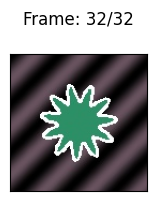

In [5]:
play_murals(train_dir, sample_mural_ids(1, 1), 0.1)

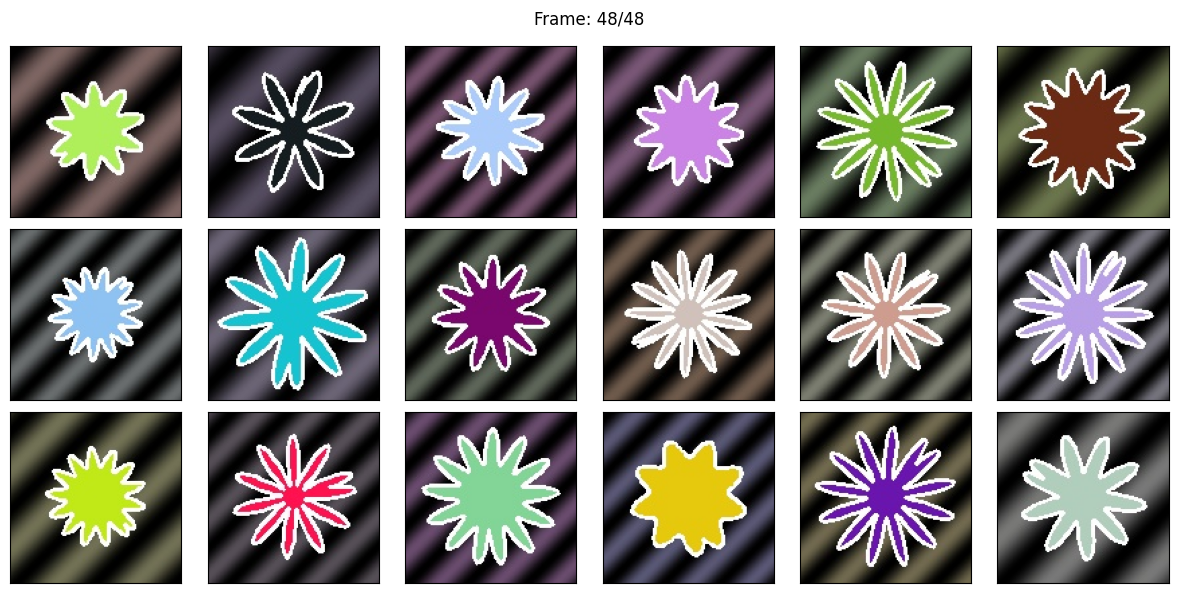

In [6]:
play_murals(train_dir, sample_mural_ids(3, 6), 0.1)

In [7]:
def unscramble_gradient(scrambled_colors):
    colors = np.array(scrambled_colors, dtype=np.float32)
    pca = PCA(n_components=1)
    projected_1d = pca.fit_transform(colors).flatten()
    sort_indices = np.argsort(projected_1d)
    return sort_indices

In [8]:
def get_main_color(path, square_half_size=3):
    img = np.array(Image.open(path))
    return img[64-square_half_size:63+square_half_size+1, 64-square_half_size:63+square_half_size+1].reshape(-1, 3).mean(axis=0)

In [9]:
def get_ordering_of_group(mural_path):
    inner_paths = sorted(os.listdir(mural_path))
    colors = np.zeros((len(inner_paths), 3))
    for i in range(len(inner_paths)):
        colors[i] = get_main_color(os.path.join(mural_path, inner_paths[i]))
    indices = unscramble_gradient(colors)
    return inner_paths, indices

def play_ordering(mural_path, inner_paths, indices, spf=1):
    for frame_id, i in enumerate(indices):
        clear_output(wait=True)
        plt.figure(figsize=(5, 5))
        plt.suptitle(f'Frame: {frame_id+1}/{len(indices)}')
        path = os.path.join(mural_path, inner_paths[i])
        image = Image.open(path)
        plt.imshow(image)
        plt.xticks([])
        plt.yticks([])
        plt.show()
        time.sleep(spf)

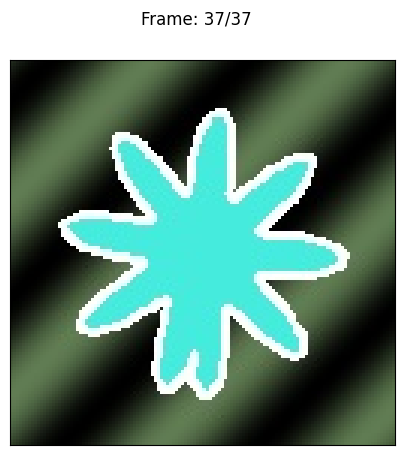

In [10]:
mural_path = '/kaggle/input/datasets/hagiabaoo/rise-open-qualifier-1-2/dataset/train/mural_001'

inner_paths, indices = get_ordering_of_group(mural_path)

play_ordering(mural_path, inner_paths, indices, spf=0.1)

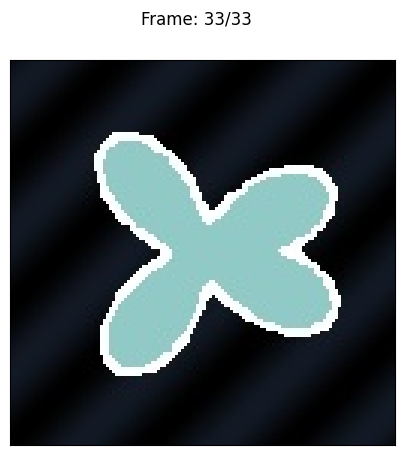

In [11]:
mural_path = '/kaggle/input/datasets/hagiabaoo/rise-open-qualifier-1-2/dataset/train/mural_002'

inner_paths, indices = get_ordering_of_group(mural_path)

play_ordering(mural_path, inner_paths, indices, spf=0.1)

In [12]:
class StarDataset(Dataset):
    def __init__(self, folder, split, step=1, transform=None): # split determines train or valid mural
        self.folder = folder
        self.split = split
        self.step = step
        self.path_bank = []
        self.pairs = []
        self.labels = []
        self.transform = transform
        self.extract_info_from_folder()
        
    def extract_info_from_folder(self):
        data_len = len(os.listdir(folder))

        if self.split[0] == "<":
            data_range = range(1, int(self.split[1:])+1)
        else:
            data_range = range(int(self.split[1:])+1, data_len+1)
        
        for subfolder_id in data_range:
            subfolder = os.path.join(folder, f'mural_{subfolder_id:03}')
            subfolder_len = len(os.listdir(subfolder))

            for i in range(subfolder_len):
                for j in range(subfolder_len):
                    if abs(i-j) < min(self.step, subfolder_len-1):
                        continue
                    self.pairs.append((len(self.path_bank)+i, len(self.path_bank)+j))
                    self.labels.append(1 if i > j else -1)
            
            self.path_bank.extend([os.path.join(subfolder, f'{i:02}.jpg') for i in range(subfolder_len)])
            
    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        path1, path2 = self.path_bank[pair[0]], self.path_bank[pair[1]]
        label = self.labels[idx]
        img1, img2 = Image.open(path1).convert('L'), Image.open(path2).convert('L')
        if self.transform is not None:
            img1, img2 = self.transform(img1), self.transform(img2)
        return img1, img2, label

folder = '/kaggle/input/datasets/hagiabaoo/rise-open-qualifier-1-2/dataset/train'

transform = v2.Compose([
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True)
])

train_ds = StarDataset(folder, split='<450', step=30, transform=transform)
valid_ds = StarDataset(folder, split='>450', step=30, transform=transform)

BATCH_SIZE = 1024

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(valid_loader)

(40, 5)

In [13]:
class StarNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, 4, 3, 1, 1),
            nn.BatchNorm2d(4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 64x64

            nn.Conv2d(4, 16, 3, 1, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 32x32

            nn.Conv2d(16, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), #16x16

            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64*16*16, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
def train_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    total, rloss = 0, 0
    for X1, X2, y in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        batch_len = len(y)
        X1, X2, y = X1.to(device), X2.to(device), y.to(device)
        output1, output2 = model(X1).squeeze(), model(X2).squeeze()
        loss = criterion(output1, output2, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        rloss += loss.item() * batch_len
        total += batch_len
        cur_loss = rloss / total
        pbar.set_postfix({'loss': f'{cur_loss:.6f}'})
        
    return cur_loss

@torch.no_grad()
def eval_one_epoch(model, criterion, valid_loader, device):
    model.eval()
    total, rloss = 0, 0
    for X1, X2, y in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        batch_len = len(y)
        X1, X2, y = X1.to(device), X2.to(device), y.to(device)
        output1, output2 = model(X1).squeeze(), model(X2).squeeze()
        loss = criterion(output1, output2, y)

        rloss += loss.item() * batch_len
        total += batch_len
        cur_loss = rloss / total
        pbar.set_postfix({'loss': f'{cur_loss:.6f}'})
        
    return cur_loss

def plot_progress(history, plot_title):
    clear_output(wait=True)
    plt.figure(figsize=(15, 5))
    plt.suptitle(plot_title)
    
    plt.subplot(1, 1, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['valid_loss'], label='valid')
    plt.legend()
    plt.title('Losses')
    plt.xlabel('epoch')
    plt.ylabel('loss')

    plt.show()

def fit(model, optimizer, criterion, scheduler, train_loader, valid_loader, device, epochs, history=None):
    if history is None:
        history = {'train_loss': [], 'valid_loss': []}

    for epoch in range(epochs):
        tloss = train_one_epoch(model, optimizer, criterion, train_loader, device)
        vloss = eval_one_epoch(model, criterion, valid_loader, device)

        history['train_loss'].append(tloss)
        history['valid_loss'].append(vloss)

        plot_progress(history, f'Epoch: {epoch+1}/{epochs} | LR: {scheduler.get_last_lr()[0]}')
        scheduler.step()
        
    return history

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

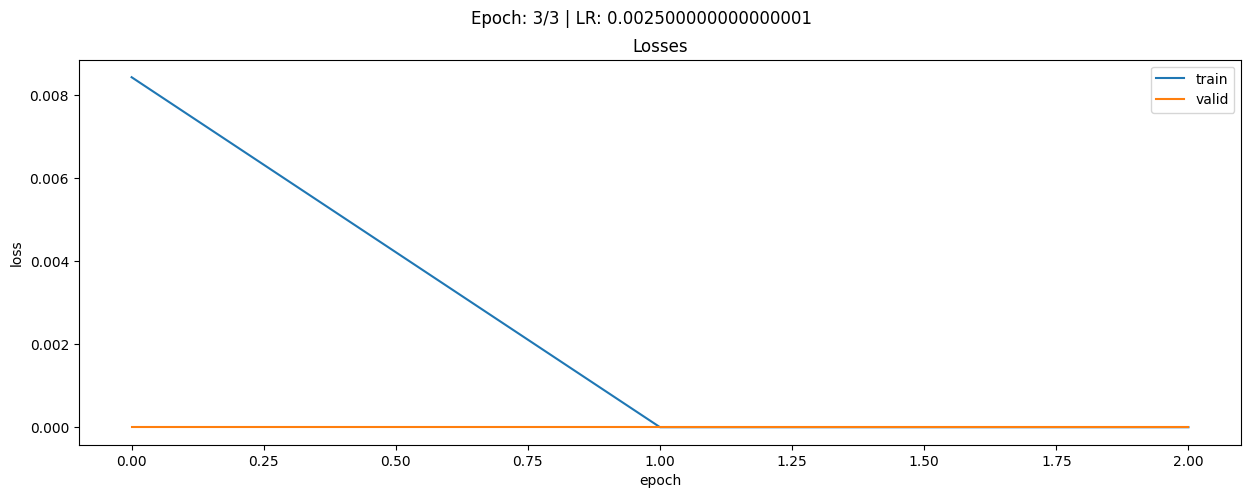

In [16]:
epochs = 3

model = StarNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)
criterion = nn.MarginRankingLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

history = fit(model, optimizer, criterion, scheduler, train_loader, valid_loader, device, epochs)

In [18]:
model = model.to('cpu')

In [ ]:
def build_submission(test_dir, transform=None):
    subm = {
        'subtaskID': [],
        'datapointID': [],
        'answer': []
    }
    for test_mural in tqdm(sorted(os.listdir(test_dir))):
        mural_path = os.path.join(test_dir, test_mural)
        inner_paths, indices = get_ordering_of_group(mural_path)
        ans = ' '.join([inner_paths[i] for i in indices])
        inner_start, inner_end = ans.split()[0], ans.split()[-1]
        image_start, image_end = Image.open(os.path.join(mural_path, inner_start)).convert("L"), Image.open(os.path.join(mural_path, inner_end)).convert("L")
        if transform is not None:
            image_start, image_end = transform(image_start), transform(image_end)
        scores = model(torch.stack([image_start, image_end])).squeeze()
        if scores[0] > scores[1]:
            ans = ' '.join([inner_paths[i] for i in indices[::-1]])
        
        subm['subtaskID'].append(1)
        subm['datapointID'].append(test_mural)
        subm['answer'].append(ans)
    subm = pd.DataFrame(subm)
    return subm

subm = build_submission('/kaggle/input/datasets/hagiabaoo/rise-open-qualifier-1-2/dataset/test', transform)
subm.to_csv("submission.csv", index=False)
subm.head()

  0%|          | 0/200 [00:00<?, ?it/s]